In [34]:
import pandas as pd

In [33]:
import os

print(os.getcwd())
print(os.listdir())

/Users/emiliaalieva/IDE/Skillfactory/PY_10_Введение в Pandas
['.DS_Store', 'requirements.txt', 'game.py', 'README.md', 'Homework_7.1.py', '.gitignore', '.venv', 'тестовый файл для отправки в гит.ipynb', '.git', '.vscode', 'test.ipynb', 'game.ipynb', 'game_v2.py', 'Skillfactory']


In [20]:
import os

os.listdir('Skillfactory')

['PY_10_Введение в Pandas', '.DS_Store', 'В']

In [21]:
os.listdir('Skillfactory/PY_10_Введение в Pandas')

['введение.ipynb', '12.ipynb', '13.ipynb', 'data']

In [22]:
covid_data = pd.read_csv(
    'Skillfactory/PY_10_Введение в Pandas/data/covid_data.csv'
)

In [25]:
covid_data = pd.read_csv('data/covid_data.csv')
display(covid_data.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/covid_data.csv'

In [26]:
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file == 'covid_data.csv':
            print(os.path.join(root, file))

./Skillfactory/PY_10_Введение в Pandas/data/covid_data.csv


In [27]:
covid_data = pd.read_csv(
    './Skillfactory/PY_10_Введение в Pandas/data/covid_data.csv'
)

In [24]:
'data/covid_data.csv'

'data/covid_data.csv'

In [30]:
vacations_data = pd.read_csv(
    './Skillfactory/PY_10_Введение в Pandas/data/contry_vacation.csv'
)

FileNotFoundError: [Errno 2] No such file or directory: './Skillfactory/PY_10_Введение в Pandas/data/contry_vacation.csv'

In [31]:
vaccinations_data = pd.read_csv('data/country_vaccinations.csv')
vaccinations_data = vaccinations_data[
    ['country', 'date', 'total_vaccinations', 
     'people_vaccinated', 'people_vaccinated_per_hundred',
     'people_fully_vaccinated', 'people_fully_vaccinated_per_hundred',
     'daily_vaccinations', 'vaccines']
]

FileNotFoundError: [Errno 2] No such file or directory: 'data/country_vaccinations.csv'

In [ ]:
covid_data = covid_data.groupby(
    ['date', 'country'], 
    as_index=False
)[['confirmed', 'deaths', 'recovered']].sum()

covid_data['date'] = pd.to_datetime(covid_data['date'])

In [10]:
covid_data = covid_data.groupby(
    ['date', 'country'], 
    as_index=False
)[['confirmed', 'deaths', 'recovered']].sum()

In [11]:
covid_data['date'] = pd.to_datetime(covid_data['date'])

In [12]:
covid_data['active'] = covid_data['confirmed'] - covid_data['deaths'] - covid_data['recovered']

In [13]:
covid_data = covid_data.sort_values(by=['country', 'date'])
covid_data['daily_confirmed'] = covid_data.groupby('country')['confirmed'].diff()
covid_data['daily_deaths'] = covid_data.groupby('country')['deaths'].diff()
covid_data['daily_recovered'] = covid_data.groupby('country')['recovered'].diff()

In [14]:
vaccinations_data['date'] = pd.to_datetime(vaccinations_data['date'])

In [16]:
covid_data['date'] = pd.to_datetime(covid_data['date'])

start_date = covid_data['date'].min().date()
end_date = covid_data['date'].max().date()

print(f'{start_date}-{end_date}')

2020-01-22-2021-05-29


In [17]:
vaccinations_data['date'] = pd.to_datetime(vaccinations_data['date'])

start_date = vaccinations_data['date'].min().date()
end_date = vaccinations_data['date'].max().date()

print(f'{start_date}-{end_date}')

2020-12-02-2021-09-06


In [28]:
covid_df = covid_data.merge(
    vaccinations_data,
    on=['date', 'country'],
    how='left'
)

print(f'{covid_df.shape[0]}-{covid_df.shape[1]}')

NameError: name 'vaccinations_data' is not defined

In [19]:
us_data = covid_df[covid_df['country'] == 'United States']

max_lethality = (
    us_data['deaths'] / us_data['confirmed'] * 100
).max()

round(max_lethality, 2)

np.float64(7.19)

In [20]:
russia_data = covid_df[covid_df['country'] == 'Russia']

recovery_mean = (
    russia_data['recovered'] / russia_data['confirmed'] * 100
).mean()

round(recovery_mean, 2)

np.float64(67.06)

In [22]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 4.9 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 4.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [14]:
covid_df = covid_data.merge(
    vaccinations_data,
    on=['date', 'country'],
    how='left'
)

NameError: name 'covid_data' is not defined

Matplotlib is building the font cache; this may take a moment.


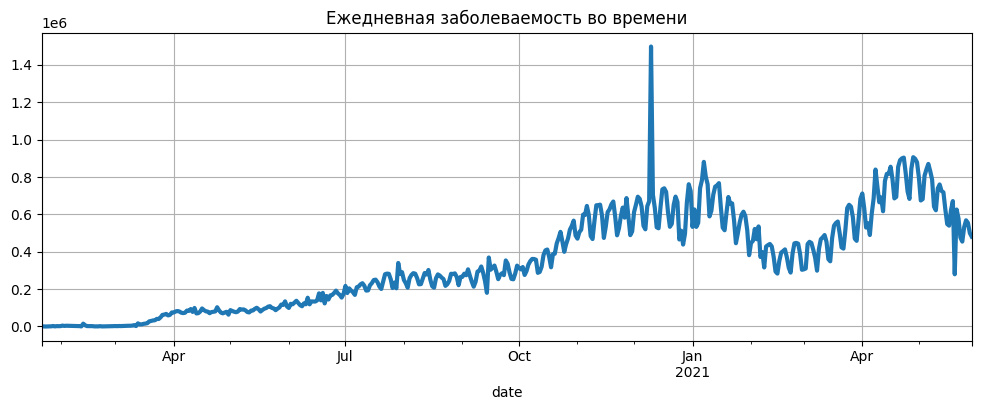

In [23]:
grouped_cases = covid_df.groupby('date')['daily_confirmed'].sum()
grouped_cases.plot(
    kind='line',
    figsize=(12, 4),
    title='Ежедневная заболеваемость во времени',
    grid = True,
    lw=3
);

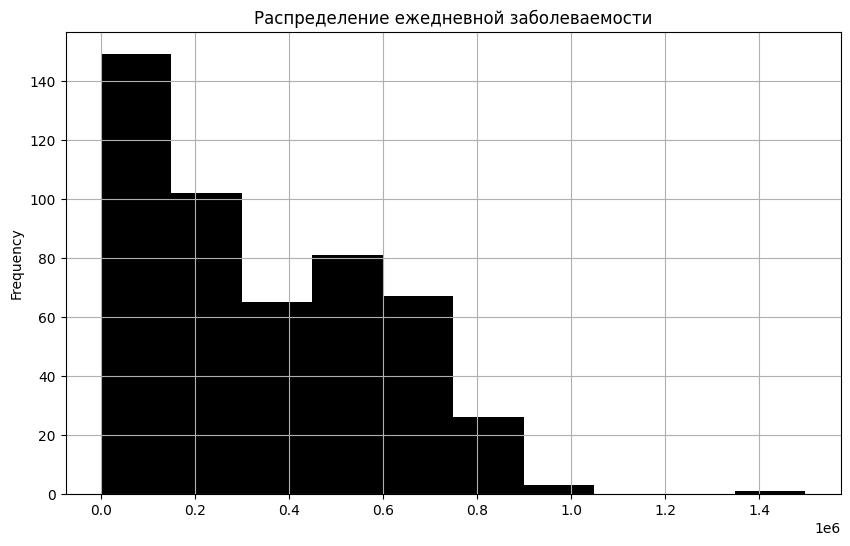

In [29]:
grouped_cases.plot(
    kind='hist',
    figsize=(10, 6),
    title='Распределение ежедневной заболеваемости',
    grid = True,
    color = 'black',
    bins=10
);

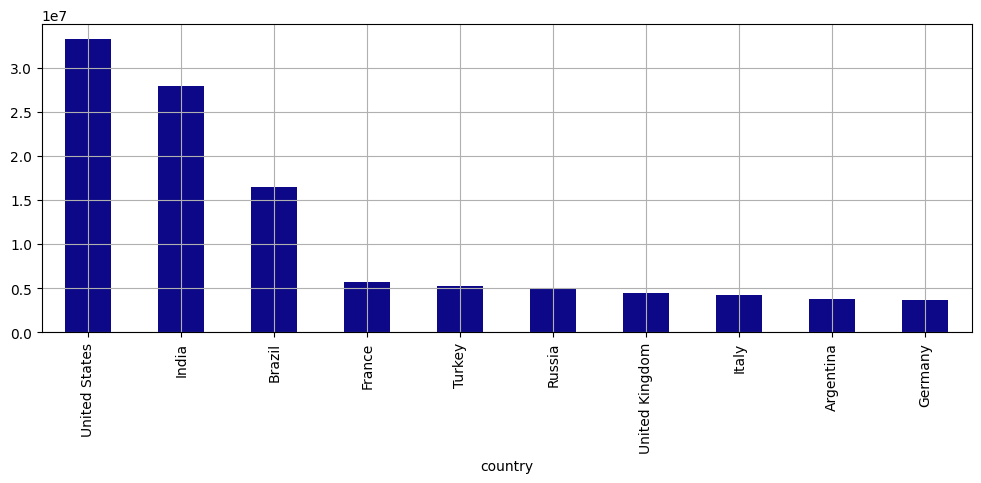

In [30]:
grouped_country = covid_df.groupby(['country'])['confirmed'].last()
grouped_country = grouped_country.nlargest(10)
grouped_country.plot(
    kind='bar',
    grid=True,
    figsize=(12, 4),
    colormap='plasma'
);


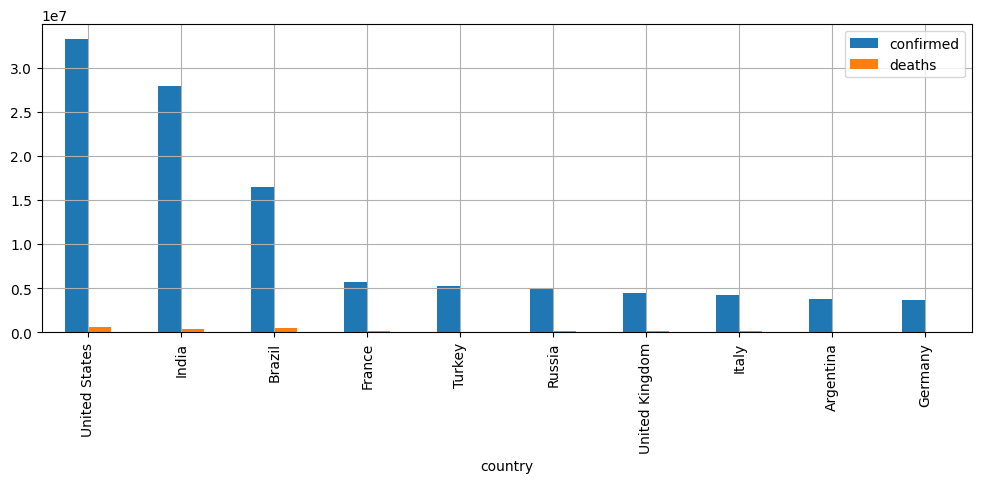

In [31]:
grouped_country = covid_df.groupby(['country'])[['confirmed', 'deaths']].last()
grouped_country = grouped_country.nlargest(10, columns=['confirmed'])
grouped_country.plot(     kind='bar',     grid=True,     figsize=(12, 4), );

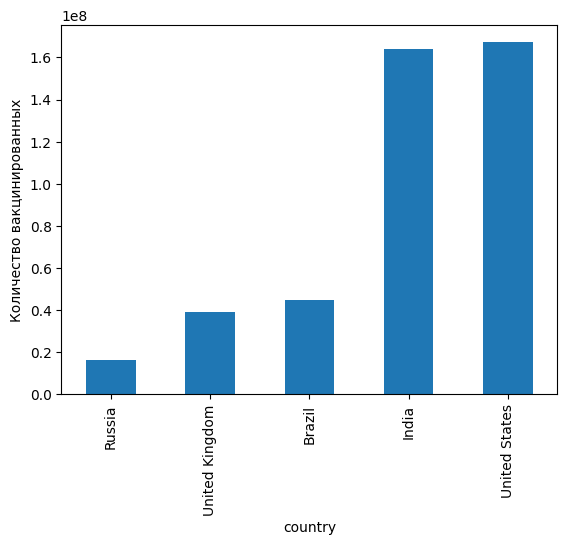

Russia


In [32]:
import matplotlib.pyplot as plt

countries = ['United States', 'India', 'Brazil', 'United Kingdom', 'Russia']

vaccinations = covid_df.groupby('country')['people_vaccinated'] \
    .max()[countries] \
    .sort_values()

vaccinations.plot(kind='bar')

plt.ylabel('Количество вакцинированных')
plt.show()

print(vaccinations.idxmin())

In [33]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
plt.style.use('default')

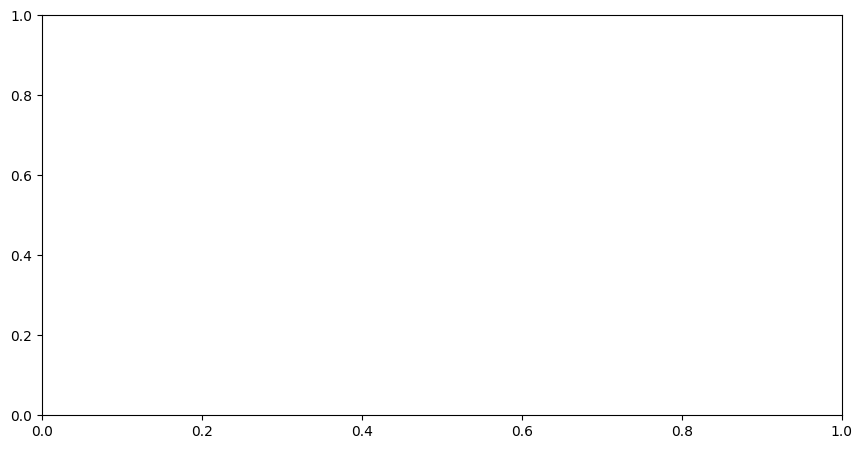

In [8]:
fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])

In [12]:
import pandas as pd

covid_df = pd.read_csv('data/covid_df.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'data/covid_df.csv'

In [13]:
covid_df = covid_data.merge(
    vaccinations_data,
    on=['date', 'country'],
    how='left'
)

covid_df.to_csv('data/covid_df.csv', index=False)

NameError: name 'covid_data' is not defined

In [10]:
us_data = covid_df[covid_df['country'] == 'United States']

fig = plt.figure(figsize=(8, 4))
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(
    x=us_data['people_fully_vaccinated'], 
    y=us_data['daily_confirmed'], 
    s=100,
    marker='o',
    c = 'blue'
);

NameError: name 'covid_df' is not defined

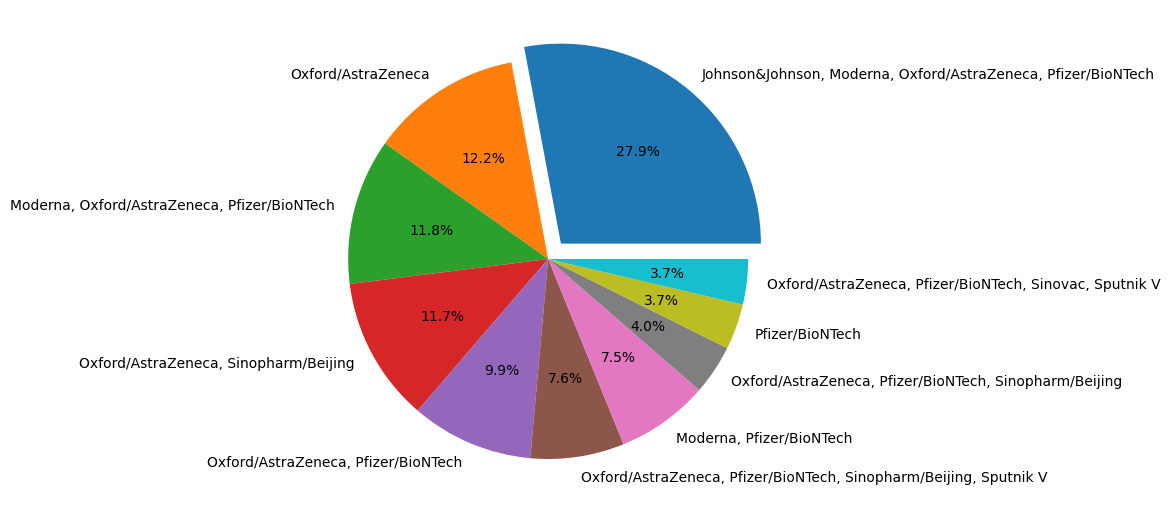

In [38]:
vaccine_combinations = covid_df['vaccines'].value_counts()[:10]
fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.pie(
    vaccine_combinations,
    labels=vaccine_combinations.index,
    autopct='%.1f%%',
    explode = [0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
);

In [2]:
china_data = covid_df[covid_df['country'] == 'China']
china_grouped = china_data.groupby(['date'])[['confirmed', 'active', 'deaths', 'recovered']].sum()


NameError: name 'covid_df' is not defined

In [35]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [36]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [37]:
countries = ['Russia', 'Australia', 'Germany', 'Canada', 'United Kingdom']
croped_covid_df = covid_df[covid_df['country'].isin(countries)]

populations = pd.DataFrame([
    ['Canada', 37664517],
    ['Germany', 83721496],
    ['Russia', 145975300],
    ['Australia', 25726900],
    ['United Kingdom', 67802690]
    ],
    columns=['country', 'population']
)
croped_covid_df = croped_covid_df.merge(populations, on=['country'])
croped_covid_df['daily_confirmed_per_hundred'] = croped_covid_df['daily_confirmed'] / croped_covid_df['population'] * 100
croped_covid_df.head()


NameError: name 'covid_df' is not defined